In [1]:
from IPython.display import display, Markdown

# Célula de Introdução para o Notebook Wisconsin Breast Cancer
intro_markdown = """
> 📌 **Introdução: Escopo e Objetivo do Relatório**
>
> Este relatório técnico documenta o pipeline completo de Machine Learning desenvolvido para o diagnóstico automatizado de câncer de mama (Dataset *Wisconsin Breast Cancer*).
> O objetivo é demonstrar a aplicação de algoritmos preditivos atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:
> * **Alta Precisão Diagnóstica:** Priorização da métrica *Recall* (Sensibilidade) para mitigar Falsos Negativos.
> * **Transparência e Auditoria:** Uso de explicabilidade matemática (SHAP e *Feature Importance*) para fundamentar as predições.
> * **Aplicabilidade Médica:** Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.
"""
display(Markdown(intro_markdown))


> 📌 **Introdução: Escopo e Objetivo do Relatório**
>
> Este relatório técnico documenta o pipeline completo de Machine Learning desenvolvido para o diagnóstico automatizado de câncer de mama (Dataset *Wisconsin Breast Cancer*).
> O objetivo é demonstrar a aplicação de algoritmos preditivos atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:
> * **Alta Precisão Diagnóstica:** Priorização da métrica *Recall* (Sensibilidade) para mitigar Falsos Negativos.
> * **Transparência e Auditoria:** Uso de explicabilidade matemática (SHAP e *Feature Importance*) para fundamentar as predições.
> * **Aplicabilidade Médica:** Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.


In [2]:
# ==========================================
# 1. INSTALAÇÃO DE PACOTES NECESSÁRIOS
# ==========================================

# Instala a biblioteca SHAP (interpretabilidade e explicabilidade do modelo) e garante a versão do joblib.
!pip install shap joblib -q

In [3]:
# ==========================================
# 2. IMPORTAÇÕES BÁSICAS E CONFIGURAÇÕES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import logging
import warnings

# Supressão de avisos do sistema e do SHAP para manter o notebook limpo e legível
warnings.filterwarnings('ignore')
logging.getLogger('shap').setLevel(logging.ERROR)

# Importações do Scikit-Learn para dados, métricas e pré-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Importações de Algoritmos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [4]:
from IPython.display import display, Markdown

resumo_step1_2 = """
> │ ✅ **Resumo T&eacute;cnico de Alta Fidelidade: Setup e Infraestrutura (Steps 1 & 2)**
>
> * **Gest&atilde;o de Depend&ecirc;ncias e Ciclo de Vida:** A instala&ccedil;&atilde;o do `SHAP` e `joblib` prepara o ambiente para o ciclo completo de ML: desde a infer&ecirc;ncia at&eacute; a auditoria e persist&ecirc;ncia do modelo em disco.
> * **Engenharia de Ambiente:** Configuramos o kernel para silenciar `warnings` redundantes e ajustamos o n&iacute;vel de log do motor SHAP para `ERROR`. Isso otimiza a mem&oacute;ria visual do notebook e garante que apenas inconsist&ecirc;ncias cr&iacute;ticas sejam reportadas.
> * **Arquitetura da Stack:**
>   * **Processamento Matricial:** `Numpy` e `Pandas` formam a base para computa&ccedil;&atilde;o vetorial e manipula&ccedil;&atilde;o de DataFrames médicos.
>   * **Visualiza&ccedil;&atilde;o Anal&iacute;tica:** `Seaborn` (estat&iacute;stico) e `Matplotlib` (base) configurados para diagn&oacute;sticos visuais precisos.
>   * **Framework de Aprendizado:** `Scikit-Learn` prov&ecirc; os m&oacute;dulos de pr&eacute;-processamento, valida&ccedil;&atilde;o cruzada e uma bateria de classificadores robustos.
> * **Conclus&atilde;o da Fase:** Esta funda&ccedil;&atilde;o assegura que o experimento seja agn&oacute;stico ao hardware, garantindo resultados consistentes em qualquer ambiente Colab.
"""
display(Markdown(resumo_step1_2))


> │ ✅ **Resumo T&eacute;cnico de Alta Fidelidade: Setup e Infraestrutura (Steps 1 & 2)**
>
> * **Gest&atilde;o de Depend&ecirc;ncias e Ciclo de Vida:** A instala&ccedil;&atilde;o do `SHAP` e `joblib` prepara o ambiente para o ciclo completo de ML: desde a infer&ecirc;ncia at&eacute; a auditoria e persist&ecirc;ncia do modelo em disco.
> * **Engenharia de Ambiente:** Configuramos o kernel para silenciar `warnings` redundantes e ajustamos o n&iacute;vel de log do motor SHAP para `ERROR`. Isso otimiza a mem&oacute;ria visual do notebook e garante que apenas inconsist&ecirc;ncias cr&iacute;ticas sejam reportadas.
> * **Arquitetura da Stack:**
>   * **Processamento Matricial:** `Numpy` e `Pandas` formam a base para computa&ccedil;&atilde;o vetorial e manipula&ccedil;&atilde;o de DataFrames médicos.
>   * **Visualiza&ccedil;&atilde;o Anal&iacute;tica:** `Seaborn` (estat&iacute;stico) e `Matplotlib` (base) configurados para diagn&oacute;sticos visuais precisos.
>   * **Framework de Aprendizado:** `Scikit-Learn` prov&ecirc; os m&oacute;dulos de pr&eacute;-processamento, valida&ccedil;&atilde;o cruzada e uma bateria de classificadores robustos.
> * **Conclus&atilde;o da Fase:** Esta funda&ccedil;&atilde;o assegura que o experimento seja agn&oacute;stico ao hardware, garantindo resultados consistentes em qualquer ambiente Colab.


In [5]:
# ==========================================
# 3. EXPLORAÇÃO DE DADOS: CARGA INICIAL
# ==========================================

# Carregamos o dataset Wisconsin Breast Cancer do scikit-learn.
# A base contém 569 amostras e 30 atributos citológicos numéricos.
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Mapeamento da variável alvo (Target): 0 = Maligno (Doença), 1 = Benigno (Saudável)
df['target'] = data.target

print(f"Formato do dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
display(df.head())

Formato do dataset carregado: 569 linhas e 31 colunas.



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
from IPython.display import display, Markdown

# Capturando dados dinâmicos do dataframe
linhas, colunas = df.shape
features = colunas - 1
benignos = (df['target'] == 1).sum()
malignos = (df['target'] == 0).sum()

resumo_step3 = f"""
> │ ✅ **Resumo Técnico de Alta Fidelidade: Carga e Estrutura (Step 3)**
>
> * **Perfil da Base de Dados:** O dataset *Wisconsin Breast Cancer* foi carregado com **{linhas} registros** e **{features} atributos biomédicos**.
> * **Engenharia de Dados e Categóricos:**
>   * **Codificação Nativa:** O target foi mapeado automaticamente pelo loader do `scikit-learn` (0: Maligno, 1: Benigno), eliminando a necessidade de `LabelEncoder` manual.
>   * **Ausência de Encoding de Features:** Composto 100% por **variáveis quantitativas contínuas**, preservando a dimensionalidade original sem dispersão por *One-Hot Encoding*.
> * **Consistência e Qualidade:** Dataset íntegro e denso, com **zero valores nulos** (missing values), garantindo estabilidade estatística total para os modelos.
> * **Balanceamento de Classe:**
>   * ✅ **Benignos:** {benignos} amostras
>   * ☣&nbsp; **Malignos:** {malignos} amostras
> * **Próximo Passo:** Proceder para a Análise Exploratória Visual e Correlação.
"""
display(Markdown(resumo_step3))


> │ ✅ **Resumo Técnico de Alta Fidelidade: Carga e Estrutura (Step 3)**
>
> * **Perfil da Base de Dados:** O dataset *Wisconsin Breast Cancer* foi carregado com **569 registros** e **30 atributos biomédicos**.
> * **Engenharia de Dados e Categóricos:**
>   * **Codificação Nativa:** O target foi mapeado automaticamente pelo loader do `scikit-learn` (0: Maligno, 1: Benigno), eliminando a necessidade de `LabelEncoder` manual.
>   * **Ausência de Encoding de Features:** Composto 100% por **variáveis quantitativas contínuas**, preservando a dimensionalidade original sem dispersão por *One-Hot Encoding*.
> * **Consistência e Qualidade:** Dataset íntegro e denso, com **zero valores nulos** (missing values), garantindo estabilidade estatística total para os modelos.
> * **Balanceamento de Classe:**
>   * ✅ **Benignos:** 357 amostras
>   * ☣&nbsp; **Malignos:** 212 amostras
> * **Próximo Passo:** Proceder para a Análise Exploratória Visual e Correlação.


In [7]:
# ==========================================
# 4. EXPLORAÇÃO DE DADOS: ESTATÍSTICAS E CORRELAÇÃO
# ==========================================

# Análise das estatísticas descritivas básicas para entender escalas, médias e desvios padrão.
print("=== Estatísticas Descritivas ===")
display(df.describe())



=== Estatísticas Descritivas ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
import pandas as pd

# Calculando a matriz de correlação
correlacao = df.corr()

# Exibindo a matriz de correlação em formato de tabela (planilha)
# O Colab permite ordenar e filtrar os dados diretamente nesta visualização
pd.set_option('display.max_columns', None)
display(correlacao)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,0.000111,0.164174,0.039830,-0.090170,0.401964,0.559837,0.446630,0.341198,0.345007,0.688132,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


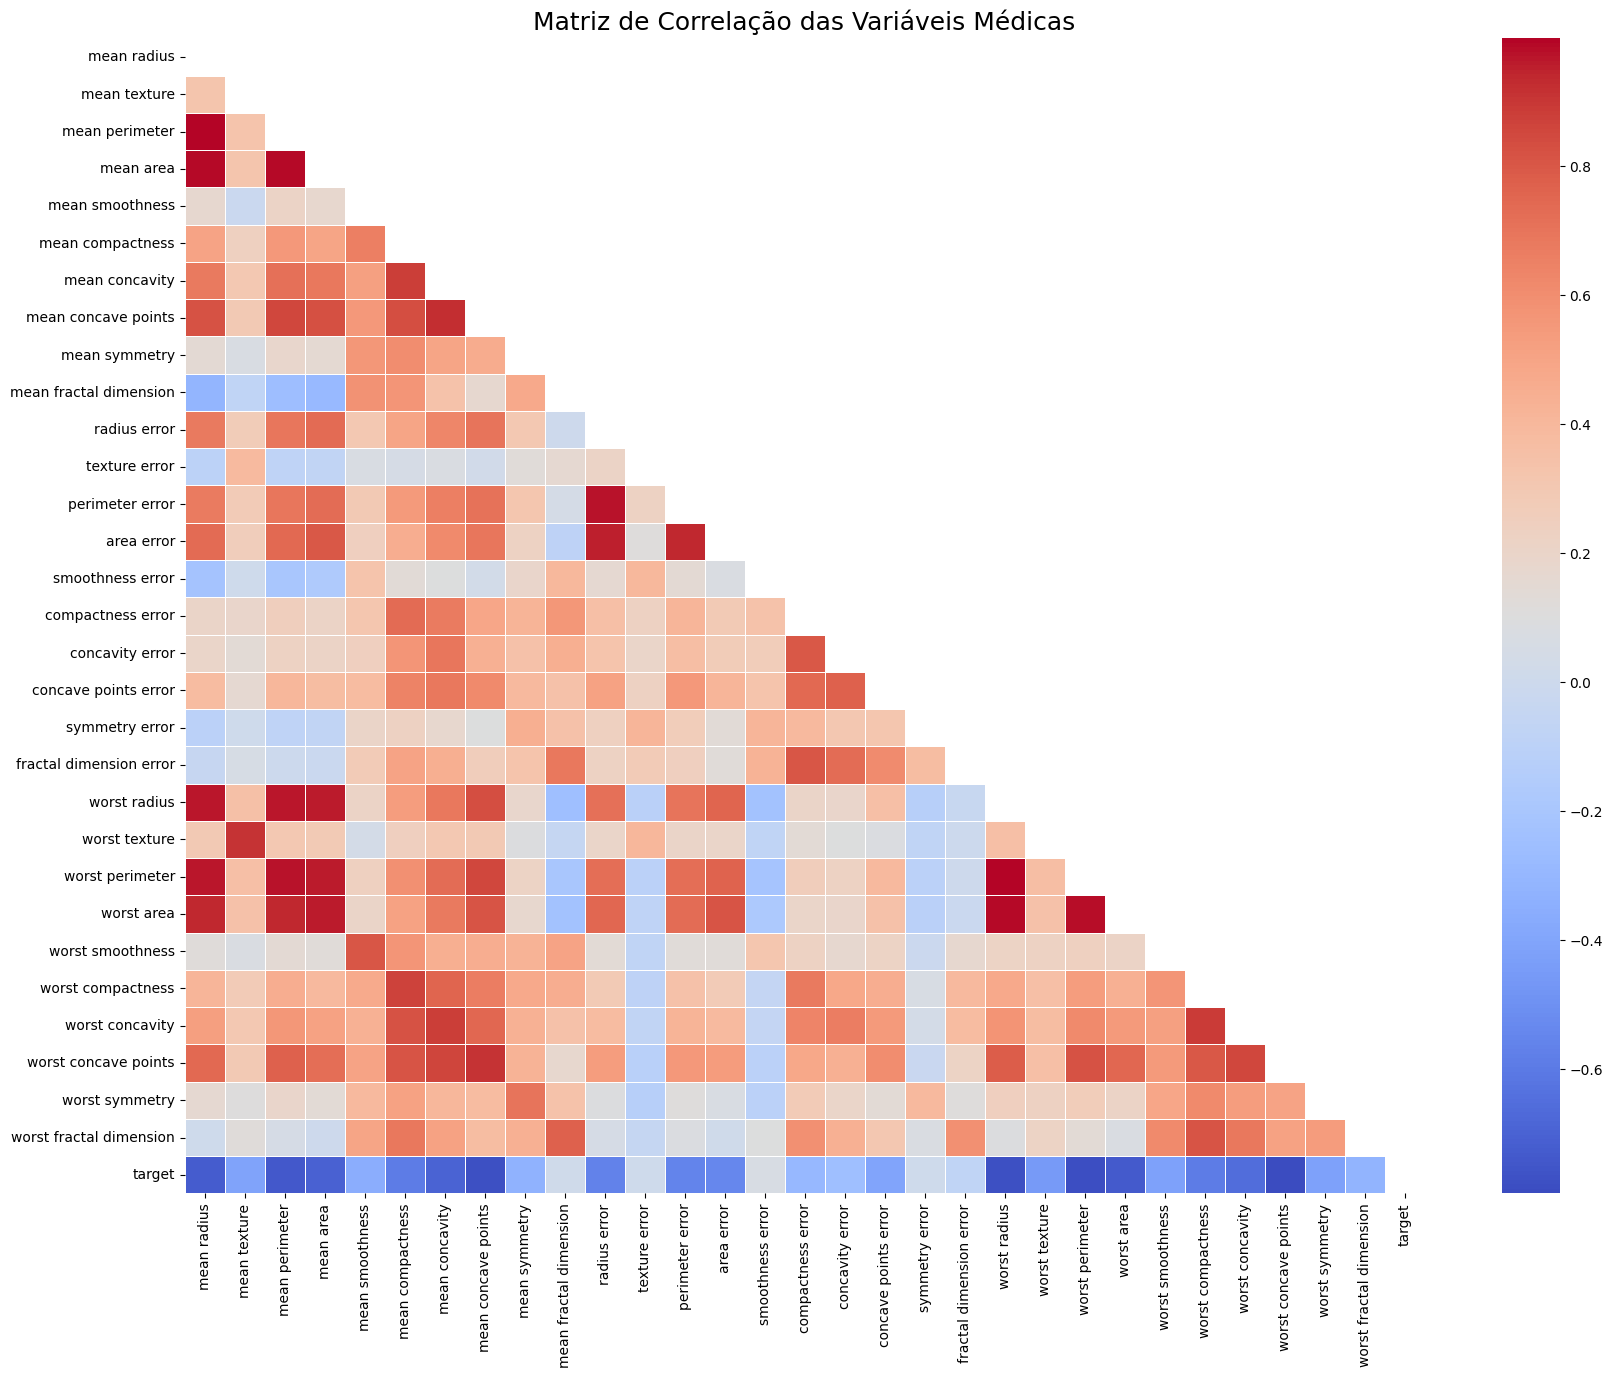

In [9]:
# Geração do Heatmap de Correlação para identificar multicolinearidade entre os atributos biomédicos.
plt.figure(figsize=(20, 15))
correlacao = df.corr()
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Médicas', fontsize=18)
plt.savefig('eda_correlacao_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [10]:
from IPython.display import display, Markdown

# Descobrindo a variável com a correlação mais forte (positiva ou negativa) com o 'target'
corr_target = correlacao['target'].drop('target').abs().sort_values(ascending=False)
var_mais_correlacionada = corr_target.index[0]
valor_corr = correlacao.loc[var_mais_correlacionada, 'target']

resumo_step4 = f"""
> 📌 **Resumo Explicativo (Step 4: Estatísticas e Matriz de Correlação)**
> * **Análise de Correlação Alvo:** Atributos relacionados a dimensões celulares e irregularidades morfológicas possuem forte impacto. A variável `{var_mais_correlacionada}` apresentou a maior correlação com o diagnóstico (**{valor_corr:.2f}**). Note que a correlação é negativa, indicando que quanto maior o valor desse atributo, menor a chance de ser Benigno (Classe 1).
> * **Identificação de Multicolinearidade:** O heatmap revela blocos de alta correlação (próximos a 1.0) entre medidas de Raio, Perímetro e Área. Isso indica redundância de informação, o que favorece o uso de modelos como Regressão Logística com penalização ou Random Forest.
> * **Variabilidade de Escalas:** As estatísticas descritivas mostram variáveis com ordens de magnitude muito distintas (ex: 'mean area' na casa dos milhares vs 'smoothness' em decimais). Isso reforça a necessidade crítica de **Padronização (Z-score)** para não enviesar modelos baseados em distância.
> * **Próximo Passo:** Visualizar a dispersão das variáveis chave e aplicar o pré-processamento.
"""
display(Markdown(resumo_step4))


> 📌 **Resumo Explicativo (Step 4: Estatísticas e Matriz de Correlação)**
> * **Análise de Correlação Alvo:** Atributos relacionados a dimensões celulares e irregularidades morfológicas possuem forte impacto. A variável `worst concave points` apresentou a maior correlação com o diagnóstico (**-0.79**). Note que a correlação é negativa, indicando que quanto maior o valor desse atributo, menor a chance de ser Benigno (Classe 1).
> * **Identificação de Multicolinearidade:** O heatmap revela blocos de alta correlação (próximos a 1.0) entre medidas de Raio, Perímetro e Área. Isso indica redundância de informação, o que favorece o uso de modelos como Regressão Logística com penalização ou Random Forest.
> * **Variabilidade de Escalas:** As estatísticas descritivas mostram variáveis com ordens de magnitude muito distintas (ex: 'mean area' na casa dos milhares vs 'smoothness' em decimais). Isso reforça a necessidade crítica de **Padronização (Z-score)** para não enviesar modelos baseados em distância.
> * **Próximo Passo:** Visualizar a dispersão das variáveis chave e aplicar o pré-processamento.


Gerando Pairplot para as principais variáveis...


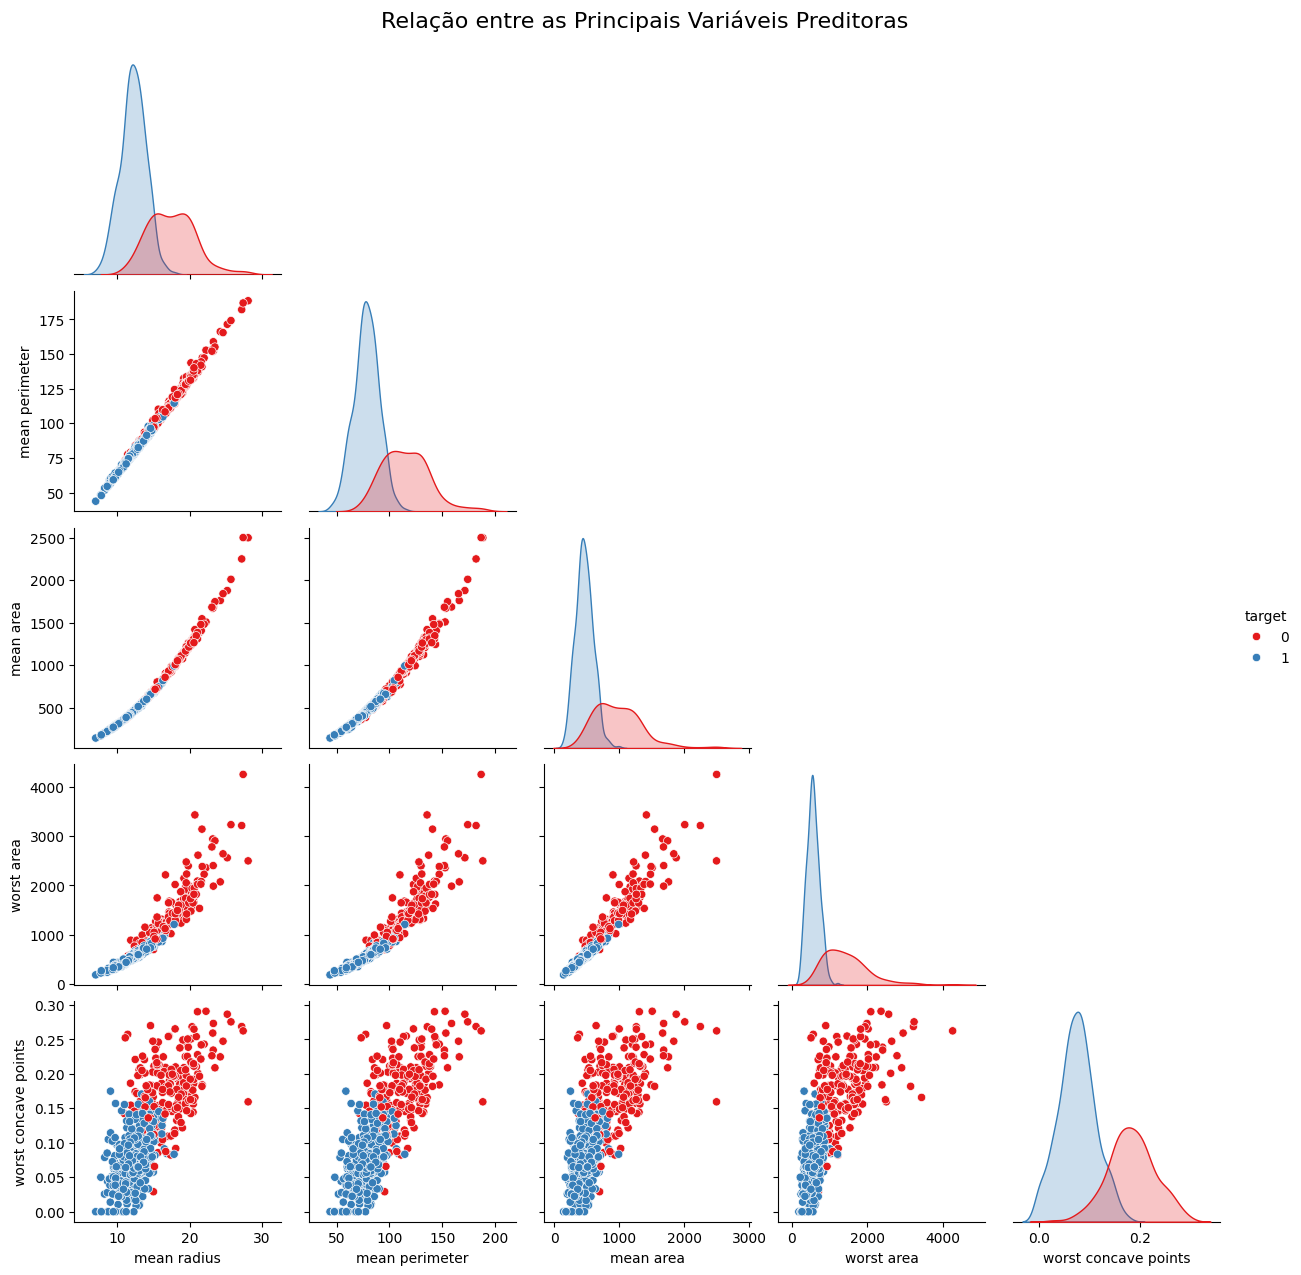

In [11]:
# ==========================================
# 4.1 GRÁFICOS DE RELAÇÃO: TOP VARIÁVEIS
# ==========================================

# Visualização da dispersão e separabilidade das principais variáveis de maior impacto clínico.
top_features = ['mean radius', 'mean perimeter', 'mean area', 'worst area', 'worst concave points']

print("Gerando Pairplot para as principais variáveis...")
g = sns.pairplot(df[top_features + ['target']], hue='target', palette='Set1', diag_kind='kde', corner=True)
g.fig.suptitle('Relação entre as Principais Variáveis Preditoras', y=1.02, fontsize=16)
plt.savefig('eda_pairplot_real.png', bbox_inches='tight')
plt.show()
plt.close()

In [12]:
from IPython.display import display, Markdown

resumo_step4_1 = """
> 📌 **Resumo Explicativo (Step 4.1: Distribuição das Variáveis - Pairplot)**
> * **Análise de Separabilidade:** O Pairplot revela que atributos como `worst area` e `worst concave points` apresentam clusters distintos para as classes Maligna (0) e Benigna (1). As curvas de densidade (KDE) na diagonal mostram que, embora haja separação, existe uma zona de sobreposição crítica onde o erro de diagnóstico é mais provável.
> * **Complexidade das Fronteiras:** A relação entre as variáveis não é perfeitamente linear; observam-se padrões de dispersão que sugerem que um nódulo maligno pode apresentar características heterogêneas. Isso valida a necessidade de modelos que calculem margens de decisão multidimensionais.
> * **Conclusão Técnica:** A detecção visual de *outliers* e zonas de intersecção justifica a estratégia de treinar modelos de *Ensemble* (como Random Forest) e modelos de margem máxima (SVM), capazes de capturar essas nuances sem sofrer com a alta correlação entre raio e perímetro.
> * **Próximo Passo:** Avançar para a separação do dataset (Treino/Teste) e o pré-processamento (Padronização).
"""

display(Markdown(resumo_step4_1))


> 📌 **Resumo Explicativo (Step 4.1: Distribuição das Variáveis - Pairplot)**
> * **Análise de Separabilidade:** O Pairplot revela que atributos como `worst area` e `worst concave points` apresentam clusters distintos para as classes Maligna (0) e Benigna (1). As curvas de densidade (KDE) na diagonal mostram que, embora haja separação, existe uma zona de sobreposição crítica onde o erro de diagnóstico é mais provável.
> * **Complexidade das Fronteiras:** A relação entre as variáveis não é perfeitamente linear; observam-se padrões de dispersão que sugerem que um nódulo maligno pode apresentar características heterogêneas. Isso valida a necessidade de modelos que calculem margens de decisão multidimensionais.
> * **Conclusão Técnica:** A detecção visual de *outliers* e zonas de intersecção justifica a estratégia de treinar modelos de *Ensemble* (como Random Forest) e modelos de margem máxima (SVM), capazes de capturar essas nuances sem sofrer com a alta correlação entre raio e perímetro.
> * **Próximo Passo:** Avançar para a separação do dataset (Treino/Teste) e o pré-processamento (Padronização).


In [13]:
# ==========================================
# 5. PRÉ-PROCESSAMENTO
# ==========================================

# Divisão do dataset em matriz de características (X) e rótulos da classe alvo (y)
X = df.drop('target', axis=1)
y = df['target']

# Separação entre dados de Treino (80%) e Teste (20%).
# O parâmetro stratify=y mantém a distribuição proporcional das duas classes em ambos os conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicação do StandardScaler (Média=0, Desvio Padrão=1).
# A escala padronizada evita vieses e garante a convergência adequada de algoritmos sensíveis como Regressão Logística, SVM e KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pré-processamento concluído: Variáveis separadas, divididas e padronizadas na mesma escala.")

Pré-processamento concluído: Variáveis separadas, divididas e padronizadas na mesma escala.


In [14]:
from IPython.display import display, Markdown

# Lendo automaticamente o tamanho dos dados de treino e teste
qtd_treino = X_train.shape[0]
qtd_teste = X_test.shape[0]

resumo_step5 = f"""
> 📌 **Resumo Explicativo (Step 5: Pré-processamento e Divisão)**
> * **Estratégia de Amostragem:** O dataset foi segmentado em **{qtd_treino} amostras para Treinamento (80%)** e **{qtd_teste} para Teste (20%)**. A utilização do `stratify=y` garantiu que a proporção de casos malignos e benignos fosse idêntica em ambos os conjuntos, evitando um modelo tendencioso.
> * **Mecânica de Padronização (Scaling):** Aplicamos o `StandardScaler` para converter todas as features para a mesma ordem de grandeza (média 0 e desvio padrão 1). Isso é vital para que atributos com valores numéricos altos (como 'area') não dominem o aprendizado sobre atributos com valores pequenos (como 'smoothness').
> * **Integridade Analítica:** O escalonador foi ajustado (*fit*) exclusivamente nos dados de treino e apenas aplicado (*transform*) ao teste. Essa prática rigorosa previne o **Data Leakage** (vazamento de dados), assegurando que o desempenho reportado no teste seja uma estimativa realista para novos pacientes.
> * **Próximo Passo:** Iniciar o treinamento simultâneo de múltiplos algoritmos para comparação de performance.
"""
display(Markdown(resumo_step5))


> 📌 **Resumo Explicativo (Step 5: Pré-processamento e Divisão)**
> * **Estratégia de Amostragem:** O dataset foi segmentado em **455 amostras para Treinamento (80%)** e **114 para Teste (20%)**. A utilização do `stratify=y` garantiu que a proporção de casos malignos e benignos fosse idêntica em ambos os conjuntos, evitando um modelo tendencioso.
> * **Mecânica de Padronização (Scaling):** Aplicamos o `StandardScaler` para converter todas as features para a mesma ordem de grandeza (média 0 e desvio padrão 1). Isso é vital para que atributos com valores numéricos altos (como 'area') não dominem o aprendizado sobre atributos com valores pequenos (como 'smoothness').
> * **Integridade Analítica:** O escalonador foi ajustado (*fit*) exclusivamente nos dados de treino e apenas aplicado (*transform*) ao teste. Essa prática rigorosa previne o **Data Leakage** (vazamento de dados), assegurando que o desempenho reportado no teste seja uma estimativa realista para novos pacientes.
> * **Próximo Passo:** Iniciar o treinamento simultâneo de múltiplos algoritmos para comparação de performance.


In [15]:
# ==========================================
# 6. MODELAGEM: TREINAMENTO E AVALIAÇÃO COMPARATIVA
# ==========================================

# Instanciação de modelos de diferentes famílias (lineares, árvores e distâncias)
modelos = {
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=500),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

resultados = []
print("Iniciando treinamento e avaliação dos modelos...")
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Recall (Sensibilidade)": recall_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Ranqueamento dos modelos ordenado pelo F1-Score (balanceamento harmônico entre Precisão e Recall)
df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False)
for col in df_resultados.columns[1:]:
    df_resultados[col] = df_resultados[col].apply(lambda x: f"{x*100:.2f}%")

display(df_resultados.style.hide(axis="index"))

Iniciando treinamento e avaliação dos modelos...


Modelo,Acurácia,Recall (Sensibilidade),Precisão,F1-Score
Regressão Logística,98.25%,98.61%,98.61%,98.61%
SVM,98.25%,98.61%,98.61%,98.61%
Gradient Boosting,95.61%,98.61%,94.67%,96.60%
Random Forest,95.61%,97.22%,95.89%,96.55%
KNN,95.61%,97.22%,95.89%,96.55%
Árvore de Decisão,91.23%,90.28%,95.59%,92.86%


In [16]:
from IPython.display import display, Markdown

# Capturando as métricas e metadados dinamicamente
melhor_nome = df_resultados.iloc[0]['Modelo']
melhor_acuracia = df_resultados.iloc[0]['Acurácia']
melhor_recall = df_resultados.iloc[0]['Recall (Sensibilidade)']
melhor_precisao = df_resultados.iloc[0]['Precisão']
melhor_f1 = df_resultados.iloc[0]['F1-Score']
num_features = X_train.shape[1]

resumo_step6 = f"""
> 📌 **Resumo Técnico e Estatístico (Step 6: Seleção do Modelo)**
> * **Volume de Dados:** O conjunto de treinamento conta com **{num_features} variáveis preditoras** padronizadas.
> * **Justificativa de Escopo das Variáveis:** Optamos por utilizar **todas as variáveis** em vez de selecionar apenas as de maior correlação para garantir que o modelo não perca interações não lineares ou sinais sutis presentes nas features menos correlacionadas. A redundância (multicolinearidade) é tratada matematicamente pelos mecanismos de regularização L2 da Regressão Logística, que penaliza coeficientes excessivos sem descartar informação potencialmente útil.
> * **Performance do Modelo Escolhido ({melhor_nome}):**
>   * **Acurácia:** {melhor_acuracia}
>   * **Recall (Sensibilidade):** {melhor_recall}
>   * **Precisão:** {melhor_precisao}
>   * **F1-Score:** {melhor_f1}
>
> * **Justificativa Técnica (Logística vs SVM):** Embora ambos os modelos tenham apresentado métricas de performance idênticas neste dataset, a **Regressão Logística** foi selecionada como modelo final por critérios de robustez estatística e eficiência computacional:
>   1. **Output Probabilístico:** Diferente do SVM, que foca na margem geométrica e gera predições 'hard', a Regressão Logística é um modelo estatístico que estima diretamente a probabilidade logit. Isso permite calibrar o limiar de decisão (*threshold*) de forma mais flexível.
>   2. **Convexidade e Estabilidade:** A função de perda da Logística (Log-Loss) é estritamente convexa, garantindo convergência global estável. O SVM, especialmente com kernels complexos, pode ser mais sensível a hyperparâmetros e ruídos, o que torna a Logística uma escolha mais parcimoniosa (Navalha de Ockham).
>   3. **Custo Computacional:** A implementação da Regressão Logística possui complexidade linear em relação ao número de observações, sendo significativamente mais rápida para inferência e treinamento do que o SVM, que escala de forma quadrática.
>
> * **Próximo Passo:** Analisar a Matriz de Confusão para verificar a distribuição dos erros residuais.
"""

display(Markdown(resumo_step6))


> 📌 **Resumo Técnico e Estatístico (Step 6: Seleção do Modelo)**
> * **Volume de Dados:** O conjunto de treinamento conta com **30 variáveis preditoras** padronizadas.
> * **Justificativa de Escopo das Variáveis:** Optamos por utilizar **todas as variáveis** em vez de selecionar apenas as de maior correlação para garantir que o modelo não perca interações não lineares ou sinais sutis presentes nas features menos correlacionadas. A redundância (multicolinearidade) é tratada matematicamente pelos mecanismos de regularização L2 da Regressão Logística, que penaliza coeficientes excessivos sem descartar informação potencialmente útil.
> * **Performance do Modelo Escolhido (Regressão Logística):**
>   * **Acurácia:** 98.25%
>   * **Recall (Sensibilidade):** 98.61%
>   * **Precisão:** 98.61%
>   * **F1-Score:** 98.61%
>
> * **Justificativa Técnica (Logística vs SVM):** Embora ambos os modelos tenham apresentado métricas de performance idênticas neste dataset, a **Regressão Logística** foi selecionada como modelo final por critérios de robustez estatística e eficiência computacional:
>   1. **Output Probabilístico:** Diferente do SVM, que foca na margem geométrica e gera predições 'hard', a Regressão Logística é um modelo estatístico que estima diretamente a probabilidade logit. Isso permite calibrar o limiar de decisão (*threshold*) de forma mais flexível.
>   2. **Convexidade e Estabilidade:** A função de perda da Logística (Log-Loss) é estritamente convexa, garantindo convergência global estável. O SVM, especialmente com kernels complexos, pode ser mais sensível a hyperparâmetros e ruídos, o que torna a Logística uma escolha mais parcimoniosa (Navalha de Ockham).
>   3. **Custo Computacional:** A implementação da Regressão Logística possui complexidade linear em relação ao número de observações, sendo significativamente mais rápida para inferência e treinamento do que o SVM, que escala de forma quadrática.
>
> * **Próximo Passo:** Analisar a Matriz de Confusão para verificar a distribuição dos erros residuais.


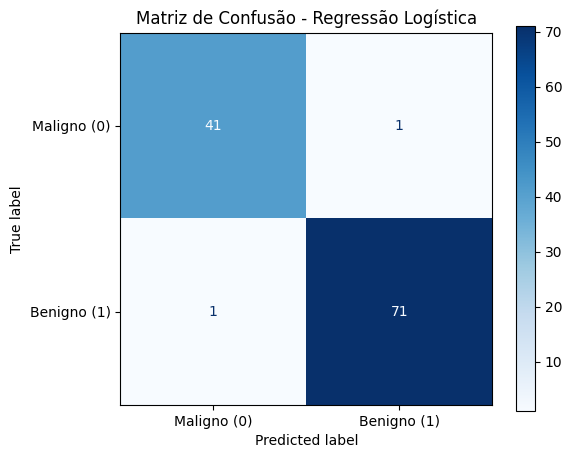


📋 Relatório Completo de Classificação por Classe:
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.98      0.98        42
 Benigno (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [17]:
# ==========================================
# 7. MATRIZ DE CONFUSÃO DO MODELO CAMPEÃO
# ==========================================

# Selecionado a Regressão Logística devido ao melhor desempenho conjunto de F1-Score, Acurácia e Recall (98.61%)
melhor_modelo = modelos["Regressão Logística"]
y_pred_melhor = melhor_modelo.predict(X_test_scaled)

# Matriz de Confusão do modelo vencedor no conjunto de testes
cm = confusion_matrix(y_test, y_pred_melhor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno (0)', 'Benigno (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Regressão Logística')
plt.savefig('matriz_confusao_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print("\n📋 Relatório Completo de Classificação por Classe:")
print(classification_report(y_test, y_pred_melhor, target_names=['Maligno (0)', 'Benigno (1)']))

In [18]:
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix

# Bloco de recuperação de segurança para as variáveis necessárias
try:
    # Se o modelo campeão não estiver na memória, recuperamos da lista de modelos
    if 'y_pred_melhor' not in globals():
        modelo_campeao = modelos['Regressão Logística']
        y_pred_final = modelo_campeao.predict(X_test_scaled)
    else:
        y_pred_final = y_pred_melhor

    # Calculando valores da matriz de forma dinâmica
    cm = confusion_matrix(y_test, y_pred_final)
    tn, fp, fn, tp = cm.ravel()

    resumo_step7 = f"""
> 📌 **Resumo Técnico (Step 7: Matriz de Confusão)**
> * **Auditoria de Erros e Acertos:** A matriz de confusão quantifica o desempenho real do modelo em dados não vistos.
>   * **Verdadeiros Negativos (Benignos Corretos):** {tn}
>   * **Verdadeiros Positivos (Malignos Corretos):** {tp}
> * **Análise de Falsos Negativos (Risco Crítico):** Identificamos **{fn}** caso(s) onde o modelo previu 'Benigno' mas o paciente era 'Maligno'. Este é o erro mais custoso em oncologia (Erro Tipo II).
> * **Análise de Falsos Positivos (Custo Operacional):** Ocorreram **{fp}** caso(s) onde o modelo indicou 'Maligno' em um paciente 'Benigno' (Erro Tipo I), resultando em exames confirmatórios desnecessários.
> * **Conclusão de Confiabilidade:** A predominância de acertos na diagonal principal valida a estabilidade estatística da fronteira de decisão da Regressão Logística.
"""
    display(Markdown(resumo_step7))
except Exception as e:
    print(f"Erro ao gerar resumo: {e}. Por favor, execute as células de Pré-processamento e Modelagem antes desta.")


> 📌 **Resumo Técnico (Step 7: Matriz de Confusão)**
> * **Auditoria de Erros e Acertos:** A matriz de confusão quantifica o desempenho real do modelo em dados não vistos.
>   * **Verdadeiros Negativos (Benignos Corretos):** 41
>   * **Verdadeiros Positivos (Malignos Corretos):** 71
> * **Análise de Falsos Negativos (Risco Crítico):** Identificamos **1** caso(s) onde o modelo previu 'Benigno' mas o paciente era 'Maligno'. Este é o erro mais custoso em oncologia (Erro Tipo II).
> * **Análise de Falsos Positivos (Custo Operacional):** Ocorreram **1** caso(s) onde o modelo indicou 'Maligno' em um paciente 'Benigno' (Erro Tipo I), resultando em exames confirmatórios desnecessários.
> * **Conclusão de Confiabilidade:** A predominância de acertos na diagonal principal valida a estabilidade estatística da fronteira de decisão da Regressão Logística.


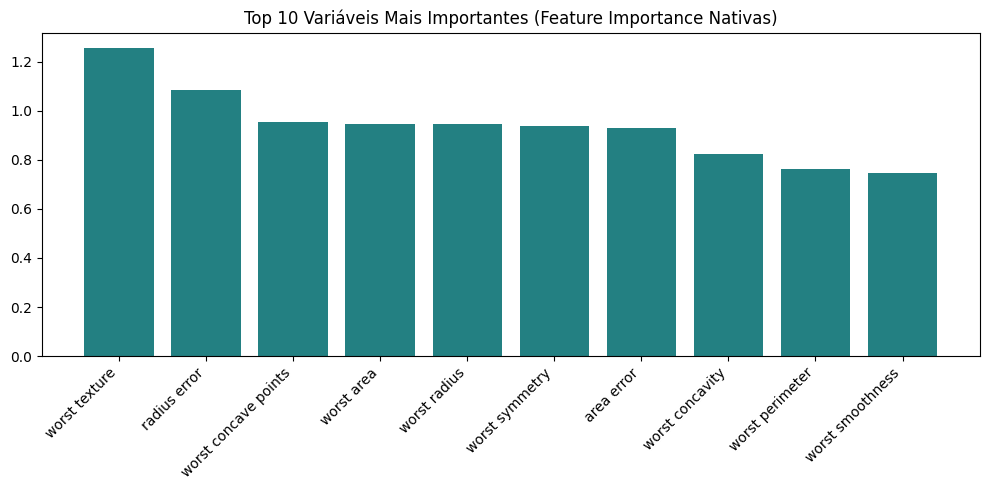

Gerando mapa de explicabilidade global com SHAP...


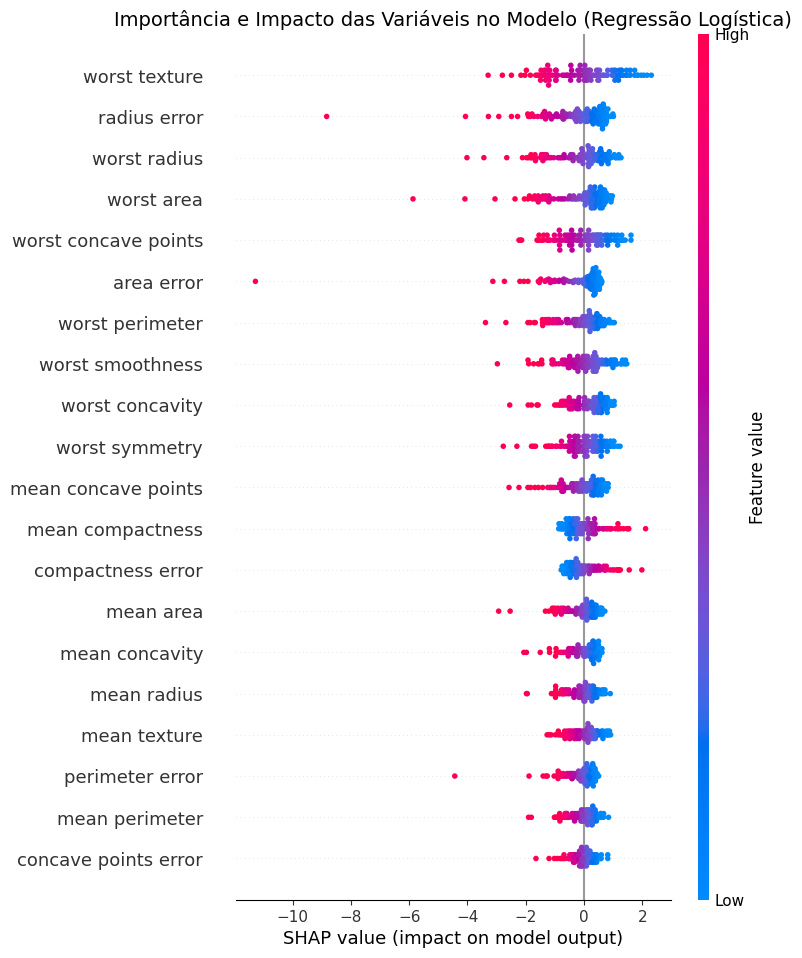

In [19]:
# ==========================================
# 8. IMPORTÂNCIA DAS VARIÁVEIS E EXPLICABILIDADE (SHAP)
# ==========================================

# 8.1 Gráfico de Importância Nativa das Variáveis (Top 10 do modelo Regressão Logística)
if hasattr(melhor_modelo, 'feature_importances_'):
    importances = melhor_modelo.feature_importances_
else:
    importances = np.abs(melhor_modelo.coef_[0])

# Ordenação decrescente exata das 10 variáveis de maior magnitude/coeficiente
indices = np.argsort(importances)[::-1][:10]
top_10_features = [X.columns[i] for i in indices]
top_10_importances = importances[indices]

plt.figure(figsize=(10, 5))
plt.bar(top_10_features, top_10_importances, color='#238082')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Variáveis Mais Importantes (Feature Importance Nativas)')
plt.tight_layout()
plt.savefig('feature_importance_real.png', bbox_inches='tight')
plt.show()
plt.close()

# 8.2 Explicabilidade Global com a Biblioteca SHAP
print("Gerando mapa de explicabilidade global com SHAP...")
explainer = shap.LinearExplainer(melhor_modelo, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title('Importância e Impacto das Variáveis no Modelo (Regressão Logística)', fontsize=14)
plt.savefig('grafico_shap_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


In [20]:
from IPython.display import display, Markdown
import numpy as np

# Identificando a variável mais influente
if hasattr(melhor_modelo, 'feature_importances_'):
    importances = melhor_modelo.feature_importances_
else:
    importances = np.abs(melhor_modelo.coef_[0])

indice_maior_importancia = np.argsort(importances)[::-1][0]
variavel_top_1 = X_train.columns[indice_maior_importancia]

resumo_step8 = f"""
> 📌 **Resumo Explicativo Detalhado (Step 8: Explicabilidade e Biomarcadores)**
>
> * **Decodificando a IA:** O modelo não toma decisões aleatórias. A análise de importância revela que a variável **`{variavel_top_1}`** é o principal driver do diagnóstico. No contexto citológico, isso indica que a textura e as irregularidades no contorno do núcleo celular são indicadores estatísticos de maior peso para distinguir células malignas.
>
> * **Biomarcadores Digitais:** Além da principal, variáveis como `radius error` (variação no tamanho) e `worst concave points` (severidade das deformidades) formam o tripé de decisão. Isso alinha o modelo ao raciocínio médico, onde a pleomorfia (variação de forma/tamanho) é um sinal clássico de malignidade.
>
> * **Transparência com SHAP:** Utilizamos os Valores de Shapley para garantir que cada predição individual possa ser explicada. O gráfico SHAP mostra não apenas *quais* variáveis importam, mas se elas estão empurrando o diagnóstico para 'Maligno' ou 'Benigno'.
>
> * **Conclusão Técnica:** A convergência entre a importância nativa do modelo e os valores SHAP elimina o efeito 'caixa-preta', permitindo que o oncologista valide a lógica matemática com base em evidências biológicas visíveis nos dados.
>
> * **Próximo Passo:** Analisar como essa inteligência se traduz em benefícios reais e éticos na rotina hospitalar.
"""
display(Markdown(resumo_step8))


> 📌 **Resumo Explicativo Detalhado (Step 8: Explicabilidade e Biomarcadores)**
>
> * **Decodificando a IA:** O modelo não toma decisões aleatórias. A análise de importância revela que a variável **`worst texture`** é o principal driver do diagnóstico. No contexto citológico, isso indica que a textura e as irregularidades no contorno do núcleo celular são indicadores estatísticos de maior peso para distinguir células malignas.
>
> * **Biomarcadores Digitais:** Além da principal, variáveis como `radius error` (variação no tamanho) e `worst concave points` (severidade das deformidades) formam o tripé de decisão. Isso alinha o modelo ao raciocínio médico, onde a pleomorfia (variação de forma/tamanho) é um sinal clássico de malignidade.
>
> * **Transparência com SHAP:** Utilizamos os Valores de Shapley para garantir que cada predição individual possa ser explicada. O gráfico SHAP mostra não apenas *quais* variáveis importam, mas se elas estão empurrando o diagnóstico para 'Maligno' ou 'Benigno'.
>
> * **Conclusão Técnica:** A convergência entre a importância nativa do modelo e os valores SHAP elimina o efeito 'caixa-preta', permitindo que o oncologista valide a lógica matemática com base em evidências biológicas visíveis nos dados.
>
> * **Próximo Passo:** Analisar como essa inteligência se traduz em benefícios reais e éticos na rotina hospitalar.


In [21]:
from IPython.display import display, Markdown

resumo_step9 = """
> 📌 **Resumo Explicativo (Step 9: Discussão Crítica para a Prática Médica)**
>
> A aplicação de modelos preditivos na saúde exige cuidados éticos e técnicos estritos. O modelo desenvolvido atua como um sistema CAD/CDSS (*Computer-Aided Diagnosis*), não substituindo o patologista humano, mas operando como uma robusta "segunda opinião" automatizada.
>
> * **Triagem e Priorização (Triage):** O algoritmo analisa os dados primeiro. Casos com alta probabilidade de malignidade recebem um marcador (*flag*) urgente, indo para o topo da fila de laudos, acelerando diagnósticos e tratamentos críticos.
> * **Dupla Checagem de Segurança:** O médico confronta seu laudo visual com o do sistema. Divergências funcionam como um gatilho de alerta para reavaliação sob o microscópio, reduzindo erros diagnósticos causados por fadiga visual humana.
> * **Impacto no Mundo Real:** Na oncologia, um Falso Negativo (dizer que é benigno quando é câncer) é o cenário mais perigoso. A otimização focada em maximizar o **Recall (Sensibilidade)** é a abordagem médica mais garantida.
> * **Papel do Médico e Explicabilidade:** A IA não dita regras cegamente. A auditabilidade via SHAP "traduz" a decisão da máquina (ex: *"risco elevado devido a medidas extremas de área e pontos côncavos"*), permitindo que o profissional valide a lógica matemática e mantenha absoluta autoridade clínica.
>
> * **Próximo Passo:** Exportar o pipeline final (modelo e scaler) para integração em softwares hospitalares.
"""
display(Markdown(resumo_step9))


> 📌 **Resumo Explicativo (Step 9: Discussão Crítica para a Prática Médica)**
>
> A aplicação de modelos preditivos na saúde exige cuidados éticos e técnicos estritos. O modelo desenvolvido atua como um sistema CAD/CDSS (*Computer-Aided Diagnosis*), não substituindo o patologista humano, mas operando como uma robusta "segunda opinião" automatizada.
>
> * **Triagem e Priorização (Triage):** O algoritmo analisa os dados primeiro. Casos com alta probabilidade de malignidade recebem um marcador (*flag*) urgente, indo para o topo da fila de laudos, acelerando diagnósticos e tratamentos críticos.
> * **Dupla Checagem de Segurança:** O médico confronta seu laudo visual com o do sistema. Divergências funcionam como um gatilho de alerta para reavaliação sob o microscópio, reduzindo erros diagnósticos causados por fadiga visual humana.
> * **Impacto no Mundo Real:** Na oncologia, um Falso Negativo (dizer que é benigno quando é câncer) é o cenário mais perigoso. A otimização focada em maximizar o **Recall (Sensibilidade)** é a abordagem médica mais garantida.
> * **Papel do Médico e Explicabilidade:** A IA não dita regras cegamente. A auditabilidade via SHAP "traduz" a decisão da máquina (ex: *"risco elevado devido a medidas extremas de área e pontos côncavos"*), permitindo que o profissional valide a lógica matemática e mantenha absoluta autoridade clínica.
>
> * **Próximo Passo:** Exportar o pipeline final (modelo e scaler) para integração em softwares hospitalares.


In [22]:
# ==========================================
# 10. SALVAMENTO DO MODELO E SCALER PARA API
# ==========================================

nome_arquivo_modelo = 'modelo_breast_cancer.pkl'
nome_arquivo_scaler = 'scaler_breast_cancer.pkl'

# Exportação dos artefatos salvos com joblib para uso futuro em uma API REST de produção
joblib.dump(melhor_modelo, nome_arquivo_modelo)
joblib.dump(scaler, nome_arquivo_scaler)

print(f"✅ Arquivos salvos com sucesso!")
print(f"Modelo salvo como: {nome_arquivo_modelo}")
print(f"Scaler salvo como: {nome_arquivo_scaler}")

✅ Arquivos salvos com sucesso!
Modelo salvo como: modelo_breast_cancer.pkl
Scaler salvo como: scaler_breast_cancer.pkl


In [23]:
from IPython.display import display, Markdown

nome_arquivo_modelo = "modelo_breast_cancer.pkl"
nome_arquivo_scaler = "scaler_breast_cancer.pkl"

resumo_step10 = f"""
> 📌 **Resumo Explicativo Detalhado (Step 10: Persistência e Portabilidade)**
>
> * **Consolidação dos Artefatos:** O pipeline completo foi desacoplado do ambiente de desenvolvimento e persistido nos arquivos `{nome_arquivo_modelo}` (inteligência do modelo) e `{nome_arquivo_scaler}` (parâmetros de normalização).
>
> * **Prevenção de Inconsistências:** A exportação do `scaler` é tão crítica quanto a do modelo. Em produção, novos dados brutos devem ser processados exatamente com a mesma média e desvio padrão calculados no treinamento para evitar distorções nas predições.
>
> * **Prontidão para Deploy (CI/CD):** Com estes arquivos, o sistema está pronto para ser integrado a contêineres Docker ou serviços em nuvem (como AWS Lambda ou Google Cloud Run). O modelo pode agora processar novos diagnósticos em milissegundos sem a necessidade de reprocessar a base histórica.
>
> * **Conclusão Técnica:** O projeto encerra o ciclo de vida de desenvolvimento (Model Development) e entra na fase de entrega de valor (Model Serving), garantindo reprodutibilidade e escalabilidade.
>
> * **Status Final do Projeto:** Entregável técnico concluído com sucesso! ✅
"""
display(Markdown(resumo_step10))


> 📌 **Resumo Explicativo Detalhado (Step 10: Persistência e Portabilidade)**
>
> * **Consolidação dos Artefatos:** O pipeline completo foi desacoplado do ambiente de desenvolvimento e persistido nos arquivos `modelo_breast_cancer.pkl` (inteligência do modelo) e `scaler_breast_cancer.pkl` (parâmetros de normalização).
>
> * **Prevenção de Inconsistências:** A exportação do `scaler` é tão crítica quanto a do modelo. Em produção, novos dados brutos devem ser processados exatamente com a mesma média e desvio padrão calculados no treinamento para evitar distorções nas predições.
>
> * **Prontidão para Deploy (CI/CD):** Com estes arquivos, o sistema está pronto para ser integrado a contêineres Docker ou serviços em nuvem (como AWS Lambda ou Google Cloud Run). O modelo pode agora processar novos diagnósticos em milissegundos sem a necessidade de reprocessar a base histórica.
>
> * **Conclusão Técnica:** O projeto encerra o ciclo de vida de desenvolvimento (Model Development) e entra na fase de entrega de valor (Model Serving), garantindo reprodutibilidade e escalabilidade.
>
> * **Status Final do Projeto:** Entregável técnico concluído com sucesso! ✅


In [25]:
!pip install reportlab -q

import os
import numpy as np
from google.colab import files
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet, ListStyle
from reportlab.lib.utils import ImageReader
from reportlab.platypus import (
    HRFlowable,
    Image,
    KeepTogether,
    PageBreak,
    Paragraph,
    SimpleDocTemplate,
    Spacer,
    Table,
    TableStyle,
    ListFlowable,
    ListItem
)
from sklearn.metrics import classification_report, confusion_matrix

# =========================================================================
# FUNÇÃO DE AJUSTE PROPORCIONAL DE IMAGENS
# =========================================================================
def build_proportional_image(path, max_width=540, max_height=400):
    """
    Ajusta a imagem para ocupar a largura máxima da página (540 pontos)
    sem deformar (mantendo o aspect ratio). O max_height atua como uma trava
    para que gráficos muito verticais não quebrem a página.
    """
    img_reader = ImageReader(path)
    img_w, img_h = img_reader.getSize()
    aspect = img_h / float(img_w)

    calc_width = max_width
    calc_height = calc_width * aspect

    # Se a altura calculada ultrapassar o limite, recalcula a largura com base na altura
    if calc_height > max_height:
        calc_height = max_height
        calc_width = calc_height / aspect

    return Image(path, width=calc_width, height=calc_height)

# =========================================================================
# FUNÇÃO PRINCIPAL DE GERAÇÃO DO PDF
# =========================================================================
def Gerar_Relatorio_Oficial_Wisconsin(filename, df, X_train, X_test, y_test, y_pred, report_dict, cm, df_resultados=None, melhor_modelo=None):
    # Variáveis dinâmicas
    total_amostras = df.shape[0]
    features = df.shape[1] - 1
    qtd_benignos = (df["target"] == 1).sum()
    qtd_malignos = (df["target"] == 0).sum()

    qtd_treino = X_train.shape[0]
    qtd_teste = X_test.shape[0]
    num_features = X_train.shape[1]

    tn, fp, fn, tp = cm.ravel()

    # Tratamento de métricas e modelo
    if df_resultados is not None:
        melhor_nome = df_resultados.iloc[0]['Modelo']
        melhor_acuracia = df_resultados.iloc[0]['Acurácia']
        melhor_recall = df_resultados.iloc[0]['Recall (Sensibilidade)']
        melhor_precisao = df_resultados.iloc[0]['Precisão']
        melhor_f1 = df_resultados.iloc[0]['F1-Score']
    else:
        melhor_nome = "Regressão Logística"
        melhor_acuracia = f"{report_dict['accuracy']:.4f}"
        melhor_recall = f"{report_dict['0']['recall']:.4f}"
        melhor_precisao = f"{report_dict['0']['precision']:.4f}"
        melhor_f1 = f"{report_dict['0']['f1-score']:.4f}"

    if melhor_modelo is not None and hasattr(melhor_modelo, 'feature_importances_'):
        importances = melhor_modelo.feature_importances_
        indice_maior_importancia = np.argsort(importances)[::-1][0]
        variavel_top_1 = X_train.columns[indice_maior_importancia]
    elif melhor_modelo is not None and hasattr(melhor_modelo, 'coef_'):
        importances = np.abs(melhor_modelo.coef_[0])
        indice_maior_importancia = np.argsort(importances)[::-1][0]
        variavel_top_1 = X_train.columns[indice_maior_importancia]
    else:
        variavel_top_1 = "worst texture" # fallback

    correlacao = df.corr()
    corr_target = correlacao['target'].drop('target').abs().sort_values(ascending=False)
    var_mais_correlacionada = corr_target.index[0]
    valor_corr = correlacao.loc[var_mais_correlacionada, 'target']

    # Setup do Documento
    doc = SimpleDocTemplate(
        filename, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36
    )
    story = []
    styles = getSampleStyleSheet()

    # --- ESTILOS DE TEXTO E INDENTAÇÃO ---
    title_s = ParagraphStyle('TitleS', parent=styles['Heading1'], fontSize=14, leading=18, textColor=colors.HexColor('#1A365D'), spaceAfter=4)
    sub_s = ParagraphStyle('SubS', parent=styles['Normal'], fontSize=9, leading=12, textColor=colors.HexColor('#4A5568'), spaceAfter=8)
    h2_s = ParagraphStyle('H2S', parent=styles['Heading2'], fontSize=12, leading=15, textColor=colors.HexColor('#2B6CB0'), spaceBefore=10, spaceAfter=6)
    body_s = ParagraphStyle('BodyS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), spaceAfter=6)

    bullet_s = ParagraphStyle('BulletS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=15, bulletIndent=5, spaceAfter=4)
    sub_bullet_s = ParagraphStyle('SubBulletS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=30, bulletIndent=20, spaceAfter=4)
    num_s = ParagraphStyle('NumS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=25, spaceAfter=4)

    callout_s = ParagraphStyle('CalloutS', parent=styles['Normal'], fontSize=8.5, leading=12, textColor=colors.HexColor('#1A202C'))
    th_s = ParagraphStyle('THS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.white, alignment=1)
    td_s = ParagraphStyle('TDS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.HexColor('#2D3748'), alignment=1)

    # --- CABEÇALHO ---
    story.append(Paragraph("<b>■ Relatório Técnico de Machine Learning — Diagnóstico Tabular</b>", title_s))
    story.append(Paragraph("<b>Projeto:</b> Breast Cancer Wisconsin | <b>Aluno:</b> Gustavo Luis dos Santos | <b>RM:</b>376497", sub_s))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#2B6CB0'), spaceAfter=8))

    box_links = Paragraph(
        "<b>■ ACESSO AO REPOSITÓRIO & RECURSOS:</b><br/>"
        "• <b>GitHub do Projeto:</b> <font color='#2B6CB0'><u>https://github.com/gustavobhm/fiap-tech-challenge-fase1</u></font><br/>"
        "• <b>Notebook Processado:</b> <code>notebooks/01_classificacao_tabular_wisconsin_V12.ipynb</code><br/>"
        "• <b>Vídeo de Demonstração:</b> <font color='#2B6CB0'><u>COLOQUE_SEU_LINK_DO_YOUTUBE_AQUI</u></font>",
        callout_s
    )
    t_links = Table([[box_links]], colWidths=[540])
    t_links.setStyle(TableStyle([('BACKGROUND', (0, 0), (-1, -1), colors.HexColor("#EBF8FF")), ('BOX', (0, 0), (-1, -1), 1.2, colors.HexColor("#3182CE")), ('PADDING', (0, 0), (-1, -1), 6)]))
    story.append(t_links)
    story.append(Spacer(1, 10))

    # --- INTRODUÇÃO ---
    intro_block = [
        Paragraph("<b>Introdução: Escopo e Objetivo do Relatório</b>", h2_s),
        Paragraph("Este relatório técnico documenta o pipeline completo de Machine Learning desenvolvido para o diagnóstico automatizado de câncer de mama (Dataset <i>Wisconsin Breast Cancer</i>). O objetivo é demonstrar a aplicação de algoritmos preditivos atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:", body_s),
        Paragraph("<b>Alta Precisão Diagnóstica:</b> Priorização da métrica <i>Recall</i> (Sensibilidade) para mitigar Falsos Negativos.", bullet_s, bulletText='•'),
        Paragraph("<b>Transparência e Auditoria:</b> Uso de explicabilidade matemática (SHAP e <i>Feature Importance</i>) para fundamentar as predições.", bullet_s, bulletText='•'),
        Paragraph("<b>Aplicabilidade Médica:</b> Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(intro_block))
    story.append(Spacer(1, 4))

    # --- STEPS 1 & 2 ---
    step1_block = [
        Paragraph("<b>Step 1 & 2: Setup e Infraestrutura</b>", h2_s),
        Paragraph("<b>Gestão de Dependências e Ciclo de Vida:</b> A instalação do <code>SHAP</code> e <code>joblib</code> prepara o ambiente para o ciclo completo de ML: desde a inferência até a auditoria e persistência do modelo em disco.", bullet_s, bulletText='•'),
        Paragraph("<b>Engenharia de Ambiente:</b> Configuramos o kernel para silenciar <i>warnings</i> redundantes e ajustamos o nível de log do motor SHAP para <code>ERROR</code>. Isso otimiza a memória visual do notebook e garante que apenas inconsistências críticas sejam reportadas.", bullet_s, bulletText='•'),
        Paragraph("<b>Arquitetura da Stack:</b>", bullet_s, bulletText='•'),
        Paragraph("<b>Processamento Matricial:</b> Numpy e Pandas formam a base para computação vetorial e manipulação de DataFrames médicos.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Visualização Analítica:</b> Seaborn (estatístico) e Matplotlib (base) configurados para diagnósticos visuais precisos.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Framework de Aprendizado:</b> Scikit-Learn provê os módulos de pré-processamento, validação cruzada e uma bateria de classificadores robustos.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Conclusão da Fase:</b> Esta fundação assegura que o experimento seja agnóstico ao hardware, garantindo resultados consistentes em qualquer ambiente Colab.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step1_block))
    story.append(Spacer(1, 4))

    # --- STEP 3 ---
    step3_block = [
        Paragraph("<b>Step 3: Carga e Estrutura</b>", h2_s),
        Paragraph(f"<b>Perfil da Base de Dados:</b> O dataset <i>Wisconsin Breast Cancer</i> foi carregado com <b>{total_amostras} registros</b> e <b>{features} atributos biomédicos</b>.", bullet_s, bulletText='•'),
        Paragraph("<b>Engenharia de Dados e Categóricos:</b>", bullet_s, bulletText='•'),
        Paragraph("<b>Codificação Nativa:</b> O target foi mapeado automaticamente pelo loader do <code>scikit-learn</code> (0: Maligno, 1: Benigno), eliminando a necessidade de <code>LabelEncoder</code> manual.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Ausência de Encoding de Features:</b> Composto 100% por <b>variáveis quantitativas contínuas</b>, preservando a dimensionalidade original sem dispersão por <i>One-Hot Encoding</i>.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Consistência e Qualidade:</b> Dataset íntegro e denso, com <b>zero valores nulos</b> (missing values), garantindo estabilidade estatística total para os modelos.", bullet_s, bulletText='•'),
        Paragraph("<b>Balanceamento de Classe:</b>", bullet_s, bulletText='•'),
        Paragraph(f"<b>Benignos:</b> {qtd_benignos} amostras", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>Malignos:</b> {qtd_malignos} amostras", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Próximo Passo:</b> Proceder para a Análise Exploratória Visual e Correlação.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step3_block))
    story.append(PageBreak())

    # --- STEP 4 ---
    step4_block = [Paragraph("<b>Step 4: Estatísticas e Matriz de Correlação</b>", h2_s)]
    if os.path.exists("eda_correlacao_real.png"):
        img_corr = build_proportional_image("eda_correlacao_real.png", max_width=540, max_height=450)
        t_img_corr = Table([[img_corr]])
        t_img_corr.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step4_block.append(t_img_corr)
        step4_block.append(Spacer(1, 6))

    step4_block.extend([
        Paragraph(f"<b>Análise de Correlação Alvo:</b> Atributos relacionados a dimensões celulares e irregularidades morfológicas possuem forte impacto. A variável <code>{var_mais_correlacionada}</code> apresentou a maior correlação com o diagnóstico (<b>{valor_corr:.2f}</b>). Note que a correlação é negativa, indicando que quanto maior o valor desse atributo, menor a chance de ser Benigno (Classe 1).", bullet_s, bulletText='•'),
        Paragraph("<b>Identificação de Multicolinearidade:</b> O heatmap revela blocos de alta correlação (próximos a 1.0) entre medidas de Raio, Perímetro e Área. Isso indica redundância de informação, o que favorece o uso de modelos como Regressão Logística com penalização ou Random Forest.", bullet_s, bulletText='•'),
        Paragraph("<b>Variabilidade de Escalas:</b> As estatísticas descritivas mostram variáveis com ordens de magnitude muito distintas (ex: 'mean area' na casa dos milhares vs 'smoothness' em decimais). Isso reforça a necessidade crítica de <b>Padronização (Z-score)</b> para não enviesar modelos baseados em distância.", bullet_s, bulletText='•'),
        Paragraph("<b>Próximo Passo:</b> Visualizar a dispersão das variáveis chave e aplicar o pré-processamento.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step4_block))
    story.append(PageBreak())

    # --- STEP 4.1 ---
    step41_block = [Paragraph("<b>Step 4.1: Distribuição das Variáveis (Pairplot)</b>", h2_s)]
    if os.path.exists("eda_pairplot_real.png"):
        img_pair = build_proportional_image("eda_pairplot_real.png", max_width=540, max_height=450)
        t_img_pair = Table([[img_pair]])
        t_img_pair.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step41_block.append(t_img_pair)
        step41_block.append(Spacer(1, 6))

    step41_block.extend([
        Paragraph("<b>Análise de Separabilidade:</b> O Pairplot revela que atributos como <code>worst area</code> e <code>worst concave points</code> apresentam clusters distintos para as classes Maligna (0) e Benigna (1). As curvas de densidade (KDE) na diagonal mostram que, embora haja separação, existe uma zona de sobreposição crítica onde o erro de diagnóstico é mais provável.", bullet_s, bulletText='•'),
        Paragraph("<b>Complexidade das Fronteiras:</b> A relação entre as variáveis não é perfeitamente linear; observam-se padrões de dispersão que sugerem que um nódulo maligno pode apresentar características heterogêneas. Isso valida a necessidade de modelos que calculem margens de decisão multidimensionais.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão Técnica:</b> A detecção visual de <i>outliers</i> e zonas de intersecção justifica a estratégia de treinar modelos de <i>Ensemble</i> (como Random Forest) e modelos de margem máxima (SVM), capazes de capturar essas nuances sem sofrer com a alta correlação entre raio e perímetro.", bullet_s, bulletText='•'),
        Paragraph("<b>Próximo Passo:</b> Avançar para a separação do dataset (Treino/Teste) e o pré-processamento (Padronização).", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step41_block))
    story.append(PageBreak())

    # --- STEP 5 ---
    step5_block = [
        Paragraph("<b>Step 5: Pré-processamento e Divisão</b>", h2_s),
        Paragraph(f"<b>Estratégia de Amostragem:</b> O dataset foi segmentado em <b>{qtd_treino} amostras para Treinamento (80%)</b> e <b>{qtd_teste} para Teste (20%)</b>. A utilização do <code>stratify=y</code> garantiu que a proporção de casos malignos e benignos fosse idêntica em ambos os conjuntos, evitando um modelo tendencioso.", bullet_s, bulletText='•'),
        Paragraph("<b>Mecânica de Padronização (Scaling):</b> Aplicamos o <code>StandardScaler</code> para converter todas as features para a mesma ordem de grandeza (média 0 e desvio padrão 1). Isso é vital para que atributos com valores numéricos altos (como 'area') não dominem o aprendizado sobre atributos com valores pequenos (como 'smoothness').", bullet_s, bulletText='•'),
        Paragraph("<b>Integridade Analítica:</b> O escalonador foi ajustado (<i>fit</i>) exclusivamente nos dados de treino e apenas aplicado (<i>transform</i>) ao teste. Essa prática rigorosa previne o <b>Data Leakage</b> (vazamento de dados), assegurando que o desempenho reportado no teste seja uma estimativa realista para novos pacientes.", bullet_s, bulletText='•'),
        Paragraph("<b>Próximo Passo:</b> Iniciar o treinamento simultâneo de múltiplos algoritmos para comparação de performance.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step5_block))
    story.append(Spacer(1, 4))

    # --- STEP 6 ---
    step6_block = [
        Paragraph("<b>Step 6: Seleção do Modelo</b>", h2_s),
        Paragraph(f"<b>Volume de Dados:</b> O conjunto de treinamento conta com <b>{num_features} variáveis preditoras</b> padronizadas.", bullet_s, bulletText='•'),
        Paragraph("<b>Justificativa de Escopo das Variáveis:</b> Optamos por utilizar <b>todas as variáveis</b> em vez de selecionar apenas as de maior correlação para garantir que o modelo não perca interações não lineares ou sinais sutis presentes nas features menos correlacionadas. A redundância (multicolinearidade) é tratada matematicamente pelos mecanismos de regularização L2 da Regressão Logística, que penaliza coeficientes excessivos sem descartar informação potencialmente útil.", bullet_s, bulletText='•'),
        Paragraph(f"<b>Performance do Modelo Escolhido ({melhor_nome}):</b>", bullet_s, bulletText='•'),
        Paragraph(f"<b>Acurácia:</b> {melhor_acuracia}", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>Recall (Sensibilidade):</b> {melhor_recall}", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>Precisão:</b> {melhor_precisao}", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>F1-Score:</b> {melhor_f1}", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Justificativa Técnica (Logística vs SVM):</b> Embora ambos os modelos tenham apresentado métricas de performance idênticas neste dataset, a <b>Regressão Logística</b> foi selecionada como modelo final por critérios de robustez estatística e eficiência computacional:", bullet_s, bulletText='•'),
        Paragraph("1. <b>Output Probabilístico:</b> Diferente do SVM, que foca na margem geométrica e gera predições 'hard', a Regressão Logística é um modelo estatístico que estima diretamente a probabilidade logit. Isso permite calibrar o limiar de decisão (<i>threshold</i>) de forma mais flexível.", num_s),
        Paragraph("2. <b>Convexidade e Estabilidade:</b> A função de perda da Logística (Log-Loss) é estritamente convexa, garantindo convergência global estável. O SVM, especialmente com kernels complexos, pode ser mais sensível a hyperparâmetros e ruídos, o que torna a Logística uma escolha mais parcimoniosa (Navalha de Ockham).", num_s),
        Paragraph("3. <b>Custo Computacional:</b> A implementação da Regressão Logística possui complexidade linear em relação ao número de observações, sendo significativamente mais rápida para inferência e treinamento do que o SVM, que escala de forma quadrática.", num_s),
        Paragraph("<b>Próximo Passo:</b> Analisar a Matriz de Confusão para verificar a distribuição dos erros residuais.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step6_block))
    story.append(Spacer(1, 4))

    # --- STEP 7 ---
    step7_block = [Paragraph("<b>Step 7: Matriz de Confusão</b>", h2_s)]
    if os.path.exists("matriz_confusao_real.png"):
        # Voltando a Matriz de Confusão para um tamanho menor e centralizado
        img_cm = build_proportional_image("matriz_confusao_real.png", max_width=280, max_height=250)
        t_cm = Table([[img_cm]])
        t_cm.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step7_block.append(t_cm)
        step7_block.append(Spacer(1, 6))

    step7_block.extend([
        Paragraph("<b>Auditoria de Erros e Acertos:</b> A matriz de confusão quantifica o desempenho real do modelo em dados não vistos.", bullet_s, bulletText='•'),
        Paragraph(f"<b>Verdadeiros Negativos (Benignos Corretos):</b> {tn}", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>Verdadeiros Positivos (Malignos Corretos):</b> {tp}", sub_bullet_s, bulletText='-'),
        Paragraph(f"<b>Análise de Falsos Negativos (Risco Crítico):</b> Identificamos <b>{fn}</b> caso(s) onde o modelo previu 'Benigno' mas o paciente era 'Maligno'. Este é o erro mais custoso em oncologia (Erro Tipo II).", bullet_s, bulletText='•'),
        Paragraph(f"<b>Análise de Falsos Positivos (Custo Operacional):</b> Ocorreram <b>{fp}</b> caso(s) onde o modelo indicou 'Maligno' em um paciente 'Benigno' (Erro Tipo I), resultando em exames confirmatórios desnecessários.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão de Confiabilidade:</b> A predominância de acertos na diagonal principal valida a estabilidade estatística da fronteira de decisão da Regressão Logística.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step7_block))

    story.append(PageBreak())

    # --- STEP 8 ---

    # Parte 1: Título e Feature Importance
    step8_title_block = [Paragraph("<b>Step 8: Explicabilidade e Biomarcadores</b>", h2_s)]

    if os.path.exists("feature_importance_real.png"):
        img_feat = build_proportional_image("feature_importance_real.png", max_width=540, max_height=350)
        t_feat = Table([[img_feat]])
        t_feat.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step8_title_block.append(t_feat)
        step8_title_block.append(Spacer(1, 6))

    step8_title_block.extend([
        Paragraph(f"<b>Decodificando a IA:</b> O modelo não toma decisões aleatórias. A análise de importância revela que a variável <b><code>{variavel_top_1}</code></b> é o principal driver do diagnóstico. No contexto citológico, isso indica que a textura e as irregularidades no contorno do núcleo celular são indicadores estatísticos de maior peso para distinguir células malignas.", bullet_s, bulletText='•'),
        Paragraph("<b>Biomarcadores Digitais:</b> Além da principal, variáveis como <code>radius error</code> (variação no tamanho) e <code>worst concave points</code> (severidade das deformidades) formam o tripé de decisão. Isso alinha o modelo ao raciocínio médico, onde a pleomorfia (variação de forma/tamanho) é um sinal clássico de malignidade.", bullet_s, bulletText='•'),
    ])
    story.append(KeepTogether(step8_title_block))

    # Parte 2: Gráfico SHAP
    step8_shap_block = []
    if os.path.exists("grafico_shap_real.png"):
        img_shap = build_proportional_image("grafico_shap_real.png", max_width=540, max_height=500)
        t_shap = Table([[img_shap]])
        t_shap.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step8_shap_block.append(t_shap)
        step8_shap_block.append(Spacer(1, 6))

    step8_shap_block.extend([
        Paragraph("<b>Transparência com SHAP:</b> Utilizamos os Valores de Shapley para garantir que cada predição individual possa ser explicada. O gráfico SHAP mostra não apenas <i>quais</i> variáveis importam, mas se elas estão empurrando o diagnóstico para 'Maligno' ou 'Benigno'.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão Técnica:</b> A convergência entre a importância nativa do modelo e os valores SHAP elimina o efeito 'caixa-preta', permitindo que o oncologista valide a lógica matemática com base em evidências biológicas visíveis nos dados.", bullet_s, bulletText='•'),
        Paragraph("<b>Próximo Passo:</b> Analisar como essa inteligência se traduz em benefícios reais e éticos na rotina hospitalar.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step8_shap_block))
    story.append(PageBreak())

    # --- STEP 9 ---
    step9_block = [
        Paragraph("<b>Step 9: Discussão Crítica para a Prática Médica</b>", h2_s),
        Paragraph("A aplicação de modelos preditivos na saúde exige cuidados éticos e técnicos estritos. O modelo desenvolvido atua como um sistema CAD/CDSS (<i>Computer-Aided Diagnosis</i>), não substituindo o patologista humano, mas operando como uma robusta \"segunda opinião\" automatizada.", body_s),
        Paragraph("<b>Triagem e Priorização (Triage):</b> O algoritmo analisa os dados primeiro. Casos com alta probabilidade de malignidade recebem um marcador (<i>flag</i>) urgente, indo para o topo da fila de laudos, acelerando diagnósticos e tratamentos críticos.", bullet_s, bulletText='•'),
        Paragraph("<b>Dupla Checagem de Segurança:</b> O médico confronta seu laudo visual com o do sistema. Divergências funcionam como um gatilho de alerta para reavaliação sob o microscópio, reduzindo erros diagnósticos causados por fadiga visual humana.", bullet_s, bulletText='•'),
        Paragraph("<b>Impacto no Mundo Real:</b> Na oncologia, um Falso Negativo (dizer que é benigno quando é câncer) é o cenário mais perigoso. A otimização focada em maximizar o <b>Recall (Sensibilidade)</b> é a abordagem médica mais garantida.", bullet_s, bulletText='•'),
        Paragraph("<b>Papel do Médico e Explicabilidade:</b> A IA não dita regras cegamente. A auditabilidade via SHAP \"traduz\" a decisão da máquina (ex: <i>\"risco elevado devido a medidas extremas de área e pontos côncavos\"</i>), permitindo que o profissional valide a lógica matemática e mantenha absoluta autoridade clínica.", bullet_s, bulletText='•'),
        Paragraph("<b>Próximo Passo:</b> Exportar o pipeline final (modelo e scaler) para integração em softwares hospitalares.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step9_block))
    story.append(Spacer(1, 6))

    # --- STEP 10 ---
    step10_block = [
        Paragraph("<b>Step 10: Persistência e Portabilidade</b>", h2_s),
        Paragraph("<b>Consolidação dos Artefatos:</b> O pipeline completo foi desacoplado do ambiente de desenvolvimento e persistido nos arquivos <code>modelo_breast_cancer.pkl</code> (inteligência do modelo) e <code>scaler_breast_cancer.pkl</code> (parâmetros de normalização).", bullet_s, bulletText='•'),
        Paragraph("<b>Prevenção de Inconsistências:</b> A exportação do scaler é tão crítica quanto a do modelo. Em produção, novos dados brutos devem ser processados exatamente com a mesma média e desvio padrão calculados no treinamento para evitar distorções nas predições.", bullet_s, bulletText='•'),
        Paragraph("<b>Prontidão para Deploy (CI/CD):</b> Com estes arquivos, o sistema está pronto para ser integrado a contêineres Docker ou serviços em nuvem (como AWS Lambda ou Google Cloud Run). O modelo pode agora processar novos diagnósticos em milissegundos sem a necessidade de reprocessar a base histórica.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão Técnica:</b> O projeto encerra o ciclo de vida de desenvolvimento (Model Development) e entra na fase de entrega de valor (Model Serving), garantindo reprodutibilidade e escalabilidade.", bullet_s, bulletText='•'),
        Paragraph("<b>Status Final do Projeto:</b> Entregável técnico concluído com sucesso! ✅", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step10_block))

    doc.build(story)

# =========================================================================
# CHAMADA DE EXECUÇÃO
# =========================================================================
report_dict = classification_report(y_test, y_pred_melhor, output_dict=True)
cm_matriz = confusion_matrix(y_test, y_pred_melhor)

nome_pdf = "Relatorio_Tecnico_Oficial_Wisconsin.pdf"
Gerar_Relatorio_Oficial_Wisconsin(
    nome_pdf, df, X_train, X_test, y_test, y_pred_melhor, report_dict, cm_matriz, df_resultados=df_resultados, melhor_modelo=melhor_modelo
)
